# 03 - Train PCOS Enhanced Diagnostic Model

Purpose:

- Train an enhanced PCOS model using clinical, lab, and ultrasound features.
- Choose a high-recall threshold using cross-validation on training data (no test leakage).
- Compare performance against the screening-only model.

Run after notebook 01, or standalone.


In [1]:
from pathlib import Path
import re
import json
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "_read_extract"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
METRIC_DIR = OUTPUT_DIR / "metrics"

for folder in [RAW_DIR, OUTPUT_DIR, FIGURE_DIR, MODEL_DIR, METRIC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

ZIP_PATH = PROJECT_ROOT / "OneDrive_1_5-11-2026.zip"
PCOS_XLSX = RAW_DIR / "(Main_Dataset)_PCOS_data_without_infertility.xlsx"
ENDO_CSV = RAW_DIR / "(Supplementary_Dataset)_structured_endometriosis_data.csv"

def ensure_small_datasets_extracted():
    """Extract only the tabular datasets if they are not already available."""
    if PCOS_XLSX.exists() and ENDO_CSV.exists():
        return
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"Cannot find {ZIP_PATH}")
    targets = {
        "(Main_Dataset)_PCOS_data_without_infertility.xlsx": PCOS_XLSX,
        "(Supplementary_Dataset)_structured_endometriosis_data.csv": ENDO_CSV,
    }
    with zipfile.ZipFile(ZIP_PATH) as zf:
        for member, destination in targets.items():
            if not destination.exists():
                with zf.open(member) as src, open(destination, "wb") as dst:
                    dst.write(src.read())

ensure_small_datasets_extracted()

def clean_column_name(name):
    name = str(name).strip().lower()
    name = name.replace("β", "beta")
    name = name.replace("marraige", "marriage")
    name = name.replace("bp _", "bp ")
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name

# Columns we never want to keep, even though they parse as numeric.
# - sl_no / patient_file_no: identifiers, no clinical signal.
# - blood_group: stored as ordinal codes (11-18) which has no meaningful order.
# - marriage_status_yrs: clinically sensitive and a poor proxy for anything
#   diagnostic; the plan flags it as unsuitable for screening.
DROP_COLUMNS = ["sl_no", "patient_file_no", "blood_group", "marriage_status_yrs"]

def load_pcos_raw():
    df = pd.read_excel(PCOS_XLSX, sheet_name="Full_new", engine="openpyxl")
    df = df.dropna(how="all").copy()
    df.columns = [clean_column_name(c) for c in df.columns]
    df = df.loc[:, ~df.columns.duplicated()].copy()
    return df

def clean_pcos_dataframe(df):
    df = df.copy()

    # Track silently-coerced non-numeric cells so the audit can flag them.
    coercion_report = {}
    for col in df.columns:
        before_non_null = df[col].notna().sum()
        coerced = pd.to_numeric(df[col], errors="coerce")
        new_nan = coerced.isna().sum() - df[col].isna().sum()
        if new_nan > 0:
            offending = df.loc[df[col].notna() & coerced.isna(), col].astype(str).unique().tolist()
            coercion_report[col] = {"coerced_to_nan": int(new_nan), "examples": offending[:5]}
        df[col] = coerced

    drop_now = [c for c in DROP_COLUMNS if c in df.columns]
    df = df.drop(columns=drop_now)

    if "pcos_y_n" not in df.columns:
        raise ValueError("Expected target column 'pcos_y_n' after cleaning column names.")

    df = df[df["pcos_y_n"].isin([0, 1])].copy()
    df["pcos_y_n"] = df["pcos_y_n"].astype(int)

    # Kaggle-style encoding uses 2 for regular and 4/5 for irregular cycles.
    if "cycle_r_i" in df.columns:
        df["cycle_irregular_flag"] = np.where(
            df["cycle_r_i"].isna(),
            np.nan,
            np.where(df["cycle_r_i"] >= 4, 1, 0),
        )

    # Conservative caps for visibly impossible or model-dominating outliers.
    caps = {
        "fsh_miu_ml": (0, 100),
        "lh_miu_ml": (0, 200),
        "fsh_lh": (0, 50),
        "vit_d3_ng_ml": (0, 150),
        "prg_ng_ml": (0, 50),
    }
    for col, (low, high) in caps.items():
        if col in df.columns:
            df[col] = df[col].clip(lower=low, upper=high)

    df.attrs["coercion_report"] = coercion_report
    df.attrs["dropped_columns"] = drop_now
    return df

pcos_raw = load_pcos_raw()
pcos = clean_pcos_dataframe(pcos_raw)
print("PCOS shape:", pcos.shape)
print("Dropped columns:", pcos.attrs["dropped_columns"])
if pcos.attrs["coercion_report"]:
    print("Non-numeric values coerced to NaN:")
    for col, info in pcos.attrs["coercion_report"].items():
        print(f"  {col}: {info['coerced_to_nan']} cell(s); examples={info['examples']}")
print(pcos["pcos_y_n"].value_counts().sort_index())



TARGET = "pcos_y_n"

# fast_food_y_n and reg_exercise_y_n are deliberately excluded.
# The plan flags lifestyle proxies as bias-prone and likely to stigmatise patients.
SCREENING_FEATURES = [
    "age_yrs",
    "bmi",
    "cycle_r_i",
    "cycle_irregular_flag",
    "cycle_length_days",
    "weight_gain_y_n",
    "hair_growth_y_n",
    "skin_darkening_y_n",
    "hair_loss_y_n",
    "pimples_y_n",
    "rbs_mg_dl",
    "bp_systolic_mmhg",
    "bp_diastolic_mmhg",
]

ENHANCED_EXTRA_FEATURES = [
    "hb_g_dl",
    "fsh_miu_ml",
    "lh_miu_ml",
    "fsh_lh",
    "tsh_miu_l",
    "amh_ng_ml",
    "prl_ng_ml",
    "vit_d3_ng_ml",
    "prg_ng_ml",
    "follicle_no_l",
    "follicle_no_r",
    "avg_f_size_l_mm",
    "avg_f_size_r_mm",
    "endometrium_mm",
]

def available(features, df):
    return [feature for feature in features if feature in df.columns]

screening_features = available(SCREENING_FEATURES, pcos)
enhanced_features = available(SCREENING_FEATURES + ENHANCED_EXTRA_FEATURES, pcos)

print("Screening features:", screening_features)
print("Enhanced features:", enhanced_features)



from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib



def make_models():
    return {
        "dummy_most_frequent": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "logistic_regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        "random_forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=4,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
        "gradient_boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ]),
    }

SCORING = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
}

def cross_validate_models(X, y, models, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=SCORING, n_jobs=-1, error_score="raise")
        row = {"model": name}
        for metric in SCORING:
            row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
            row[f"{metric}_std"] = scores[f"test_{metric}"].std()
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["roc_auc_mean", "recall_mean"], ascending=False)

def cv_oof_probabilities(model, X, y, n_splits=5):
    """Out-of-fold positive-class probabilities for threshold tuning without leakage."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_predict(model, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

def evaluate_holdout(model, X_test, y_test, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_test, proba),
        "recall": recall_score(y_test, pred),
        "specificity": recall_score(y_test, pred, pos_label=0),
        "precision": precision_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "confusion_matrix": confusion_matrix(y_test, pred).tolist(),
    }

def choose_high_recall_threshold(y_true, y_proba, min_recall=0.90):
    thresholds = np.round(np.linspace(0.05, 0.95, 181), 3)
    rows = []
    for threshold in thresholds:
        pred = (y_proba >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "recall": recall_score(y_true, pred),
            "specificity": recall_score(y_true, pred, pos_label=0),
            "precision": precision_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        })
    table = pd.DataFrame(rows)
    candidates = table[table["recall"] >= min_recall]
    if len(candidates):
        chosen = candidates.sort_values(["specificity", "precision", "f1"], ascending=False).iloc[0]
    else:
        chosen = table.sort_values(["f1", "balanced_accuracy"], ascending=False).iloc[0]
    return chosen, table

def make_risk_tier(threshold):
    """Risk tiers anchored to the model's action threshold so labels never contradict predictions."""
    high_cutoff = min(0.90, threshold + 0.20)
    def risk_tier(probability):
        if probability < threshold:
            return "Low"
        if probability < high_cutoff:
            return "Moderate"
        return "High"
    return risk_tier

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


PCOS shape: (541, 41)
Dropped columns: ['sl_no', 'patient_file_no', 'blood_group', 'marriage_status_yrs']
Non-numeric values coerced to NaN:
  ii_beta_hcg_miu_ml: 1 cell(s); examples=['1.99.']
  amh_ng_ml: 1 cell(s); examples=['a']
pcos_y_n
0    364
1    177
Name: count, dtype: int64
Screening features: ['age_yrs', 'bmi', 'cycle_r_i', 'cycle_irregular_flag', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'rbs_mg_dl', 'bp_systolic_mmhg', 'bp_diastolic_mmhg']
Enhanced features: ['age_yrs', 'bmi', 'cycle_r_i', 'cycle_irregular_flag', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'rbs_mg_dl', 'bp_systolic_mmhg', 'bp_diastolic_mmhg', 'hb_g_dl', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh', 'tsh_miu_l', 'amh_ng_ml', 'prl_ng_ml', 'vit_d3_ng_ml', 'prg_ng_ml', 'follicle_no_l', 'follicle_no_r', 'avg_f_size_l_mm', 'avg_f_size_r_mm', 'endometrium_mm']


## Prepare Enhanced Dataset


In [2]:
X = pcos[enhanced_features].copy()
y = pcos[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Enhanced feature count:", len(enhanced_features))
print("Train:", X_train.shape, "Test:", X_test.shape)


Enhanced feature count: 27
Train: (405, 27) Test: (136, 27)


## Cross-Validate Candidate Models


In [3]:
models = make_models()
cv_results = cross_validate_models(X_train, y_train, models)
cv_results.to_csv(METRIC_DIR / "enhanced_cv_results.csv", index=False)
cv_results


,model,roc_auc_mean,roc_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std
2,random_forest,0.955459,0.019567,0.849003,0.049609,0.840433,0.045338,0.842918,0.027036,0.884030,0.020261
3,gradient_boosting,0.944660,0.026967,0.774074,0.035579,0.846258,0.041134,0.807531,0.024415,0.852121,0.017190
1,logistic_regression,0.943676,0.035213,0.870370,0.118698,0.815020,0.107849,0.836459,0.091677,0.883636,0.067838
0,dummy_most_frequent,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000


## Fit Best Enhanced Model


In [4]:
best_name = cv_results.iloc[0]["model"]
best_enhanced_model = models[best_name]
print("Best enhanced model:", best_name)

oof_proba_train = cv_oof_probabilities(best_enhanced_model, X_train, y_train)
chosen_threshold, threshold_table = choose_high_recall_threshold(y_train, oof_proba_train, min_recall=0.90)
threshold = float(chosen_threshold["threshold"])
threshold_table.to_csv(METRIC_DIR / "enhanced_threshold_table.csv", index=False)
print("Chosen threshold (from training CV):")
display(chosen_threshold)

best_enhanced_model.fit(X_train, y_train)
test_proba = best_enhanced_model.predict_proba(X_test)[:, 1]

enhanced_metrics = evaluate_holdout(best_enhanced_model, X_test, y_test, threshold=threshold)
save_json(enhanced_metrics, METRIC_DIR / "enhanced_holdout_metrics.json")
enhanced_metrics


Best enhanced model: random_forest


Chosen threshold (from training CV):


threshold            0.380000
recall               0.909774
specificity          0.841912
precision            0.737805
f1                   0.814815
balanced_accuracy    0.875843
Name: 66, dtype: float64

{'threshold': 0.38,
 'roc_auc': np.float64(0.9528162055335969),
 'recall': 0.8863636363636364,
 'specificity': 0.9021739130434783,
 'precision': 0.8125,
 'f1': 0.8478260869565217,
 'balanced_accuracy': np.float64(0.8942687747035574),
 'confusion_matrix': [[83, 9], [5, 39]]}

## Confusion Matrix and Curves


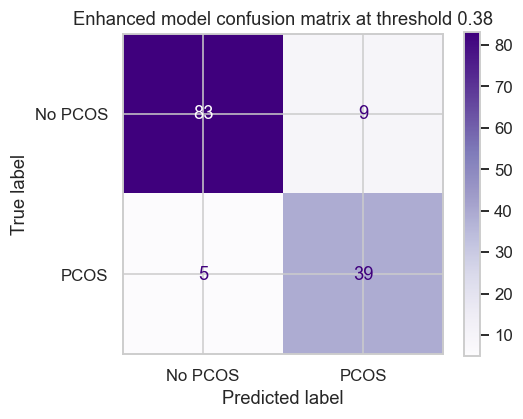

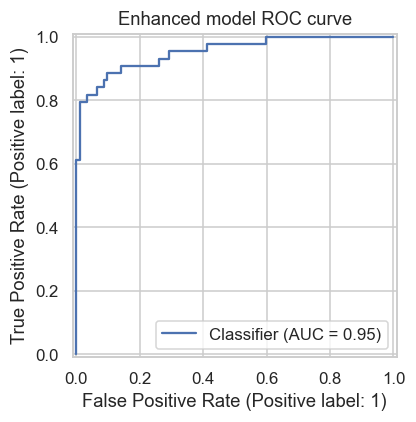

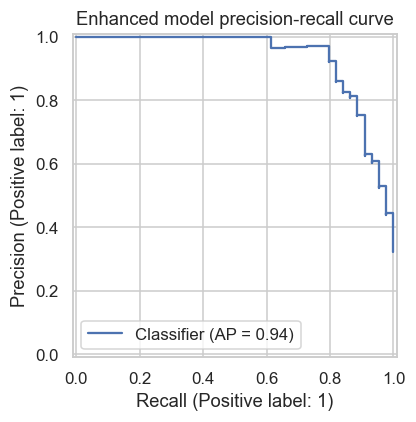

In [5]:
pred = (test_proba >= threshold).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["No PCOS", "PCOS"], cmap="Purples", ax=ax)
ax.set_title(f"Enhanced model confusion matrix at threshold {threshold:.2f}")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "enhanced_confusion_matrix.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, test_proba, ax=ax)
ax.set_title("Enhanced model ROC curve")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "enhanced_roc_curve.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
PrecisionRecallDisplay.from_predictions(y_test, test_proba, ax=ax)
ax.set_title("Enhanced model precision-recall curve")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "enhanced_precision_recall_curve.png", dpi=160)
plt.show()


## Save Enhanced Model Artifact


In [6]:
background_sample = X_train.sample(min(100, len(X_train)), random_state=RANDOM_STATE)
shap_background = background_sample.copy()
for _, transformer in best_enhanced_model.steps[:-1]:
    shap_background = transformer.transform(shap_background)

artifact = {
    "model": best_enhanced_model,
    "model_name": best_name,
    "features": enhanced_features,
    "target": TARGET,
    "threshold": threshold,
    "threshold_source": "cv_oof_training",
    "metrics": enhanced_metrics,
    "shap_background_transformed": np.asarray(shap_background),
    "notes": "Enhanced PCOS diagnostic-support model using labs and ultrasound features.",
}

artifact_path = MODEL_DIR / "pcos_enhanced_model.joblib"
joblib.dump(artifact, artifact_path)
print("Saved:", artifact_path)


Saved: C:\Users\kex03\Downloads\biohackathon\outputs\models\pcos_enhanced_model.joblib
